## **COMPARATIVE ANALYSIS OF MACHINE LEARNING ALGORITHMS FOR PREDICTION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Scikit-learn: Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Scikit-learn: Model Selection
from sklearn.model_selection import train_test_split

# Scikit-learn: Classification Algorithms
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Scikit-learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Scikit-learn: Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("✅ All libraries imported successfully!\n")

✅ All libraries imported successfully!



**Load Datasets**

In [ ]:
MBTI_PATH   = "/content/drive/MyDrive/IIS_Mini_Project/mbti_dataset/mbti_1.csv"          # Dataset 1: MBTI Personality
SURVEY_PATH = "/content/drive/MyDrive/IIS_Mini_Project/survey_dataset/responses.csv"      # Dataset 2: Young People Survey

try:
    df_mbti   = pd.read_csv(MBTI_PATH)
    df_survey = pd.read_csv(SURVEY_PATH)
    print("✅ Both datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"File not found: {e}")
    print("   Please update MBTI_PATH and SURVEY_PATH with correct file locations.")
    raise

✅ Both datasets loaded successfully!


**Basic Data Exploration**

In [ ]:
print("\n" + "="*60)
print("DATASET 1 — MBTI PERSONALITY (TEXT DATA)")
print("="*60)

print("\n📌 First 5 rows:")
print(df_mbti.head())

print("\n📌 Dataset Info:")
print(df_mbti.info())

print("\n📌 Personality Type Distribution (Top 16):")
print(df_mbti['type'].value_counts())


print("\n" + "="*60)
print("DATASET 2 — YOUNG PEOPLE SURVEY (STRUCTURED DATA)")
print("="*60)

print("\n📌 First 5 rows:")
print(df_survey.head())

print("\n📌 Dataset Info:")
df_survey.info()

# Select 'Alcohol' as target column (a behavioral/personality proxy)
# Other options are : 'Smoking', 'Healthy eating'
TARGET_COLUMN = 'Alcohol'

print(f"\n📌 Target Column — '{TARGET_COLUMN}' Value Counts:")
print(df_survey[TARGET_COLUMN].value_counts())


DATASET 1 — MBTI PERSONALITY (TEXT DATA)

📌 First 5 rows:
   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB
None

📌 Personality Type Distribution (Top 16):
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtyp

**DATASET 1 - TEXT-BASED PERSONALITY PREDICTION (MBTI)**

**TEXT PREPROCESSING**

In [ ]:
def clean_text(text):
    """
    Cleans raw social media text:
      - Lowercase everything
      - Strip URLs (http/https links)
      - Remove special characters and digits
      - Collapse extra whitespace
    """
    text = text.lower()                                # Convert to lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)               # Keep only letters & spaces
    text = re.sub(r'\s+', ' ', text).strip()           # Remove extra spaces
    return text

print("\nCleaning text data...")
df_mbti['clean_posts'] = df_mbti['posts'].apply(clean_text)
print("...")
print("Text cleaned.")
print("\nSample cleaned text:")
print(df_mbti['clean_posts'].iloc[0][:200], "...")


Cleaning text data...
...
Text cleaned.

Sample cleaned text:
and intj moments sportscenter not top ten plays prankswhat has been the most lifechanging experience in your life on repeat for most of todaymay the perc experience immerse youthe last thing my infj f ...


**TF-IDF VECTORIZATION**

In [ ]:
# TF-IDF converts text into numerical feature vectors.
# max_features=5000 keeps computation manageable for Colab.

print("\nApplying TF-IDF Vectorization (max 5000 features)...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_text = tfidf.fit_transform(df_mbti['clean_posts'])  # Feature matrix (sparse)
y_text = df_mbti['type']                              # Target labels (16 MBTI types)

print(f"TF-IDF shape: {X_text.shape}  →  {X_text.shape[0]} samples, {X_text.shape[1]} features")


Applying TF-IDF Vectorization (max 5000 features)...
TF-IDF shape: (8675, 5000)  →  8675 samples, 5000 features


**TRAIN / TEST SPLIT (Dataset 1)**

In [ ]:
# 80% training, 20% testing; stratify keeps class balance.

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)
print(f"\nSplit → Train: {X_train_text.shape[0]} samples | Test: {X_test_text.shape[0]} samples")


Split → Train: 6940 samples | Test: 1735 samples


**TRAIN MODELS ON DATASET 1**

In [ ]:
# We use MultinomialNB for text (requires non-negative values),
# LogisticRegression, and LinearSVC (fast SVM variant).

def evaluate_model(model_name, y_true, y_pred):
    """Returns a dict of evaluation metrics for a given model."""
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
    }

text_results = []   # Stores metric dicts for Dataset 1

In [ ]:
# ── Model 1: Naive Bayes (Multinomial) ──────────────────────
print("Training Naive Bayes on MBTI data...")
nb_text = MultinomialNB()
nb_text.fit(X_train_text, y_train_text)
y_pred_nb_text = nb_text.predict(X_test_text)
text_results.append(evaluate_model("Naive Bayes", y_test_text, y_pred_nb_text))
print(f"   Accuracy: {text_results[-1]['Accuracy']}%")

Training Naive Bayes on MBTI data...
   Accuracy: 36.31%


In [ ]:
# ── Model 2: Logistic Regression ────────────────────────────
print("Training Logistic Regression on MBTI data...")
lr_text = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_text.fit(X_train_text, y_train_text)
y_pred_lr_text = lr_text.predict(X_test_text)
text_results.append(evaluate_model("Logistic Regression", y_test_text, y_pred_lr_text))
print(f"   Accuracy: {text_results[-1]['Accuracy']}%")

Training Logistic Regression on MBTI data...
   Accuracy: 62.54%


In [ ]:
# ── Model 3: SVM (LinearSVC) ────────────────────────────────
print("Training SVM (LinearSVC) on MBTI data...")
svm_text = LinearSVC(max_iter=2000, random_state=42)
svm_text.fit(X_train_text, y_train_text)
y_pred_svm_text = svm_text.predict(X_test_text)
text_results.append(evaluate_model("SVM", y_test_text, y_pred_svm_text))
print(f"   Accuracy: {text_results[-1]['Accuracy']}%")

Training SVM (LinearSVC) on MBTI data...
   Accuracy: 60.17%


In [ ]:
# Results table for Dataset 1
df_text_results = pd.DataFrame(text_results)
print("DATASET 1 — MODEL COMPARISON TABLE:")
print(df_text_results.to_string(index=False))

DATASET 1 — MODEL COMPARISON TABLE:
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes     36.31      42.63   36.31     28.10
        Naive Bayes     36.31      42.63   36.31     28.10
Logistic Regression     62.54      63.88   62.54     59.82
                SVM     60.17      60.08   60.17     59.38


**DATASET 2 - STRUCTURED DATA PERSONALITY/BEHAVIOR PREDICTION**

**PREPARE STRUCTURED DATA (Survey)**

In [ ]:
# Keep only numeric columns for features (drop target + non-numeric)
df_survey_clean = df_survey.copy()

# Separate features and target
y_survey_raw = df_survey_clean[TARGET_COLUMN].dropna()
df_features   = df_survey_clean.drop(columns=[TARGET_COLUMN])

# Keep only numeric columns
df_features = df_features.select_dtypes(include=[np.number])

# Align rows: only keep rows where target is not null
df_features = df_features.loc[y_survey_raw.index]

# ── Handle missing values ────────────────────────────────────
# Fill NaN values with the median of each column (robust to outliers)
print(f"Handling missing values...")
missing_before = df_features.isnull().sum().sum()
df_features.fillna(df_features.median(), inplace=True)
print(f"   Filled {missing_before} missing values with column medians.")

# ── Encode target variable ───────────────────────────────────
# LabelEncoder converts string categories → integers
le = LabelEncoder()
y_survey = le.fit_transform(y_survey_raw)

print(f"\n Features shape : {df_features.shape}")
print(f" Target classes  : {list(le.classes_)}")

# Feature matrix
X_survey = df_features.values

Handling missing values...
   Filled 567 missing values with column medians.

 Features shape : (1005, 139)
 Target classes  : ['drink a lot', 'never', 'social drinker']


**TRAIN / TEST SPLIT (Dataset 2)**

In [ ]:
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_survey, y_survey,
    test_size=0.2,
    random_state=42,
    stratify=y_survey
)
print(f"Split → Train: {X_train_sv.shape[0]} samples | Test: {X_test_sv.shape[0]} samples")

# Scale features for LR and SVM (GaussianNB does not require scaling)
scaler = StandardScaler()
X_train_sv_scaled = scaler.fit_transform(X_train_sv)
X_test_sv_scaled  = scaler.transform(X_test_sv)

Split → Train: 804 samples | Test: 201 samples


**TRAIN MODELS ON DATASET 2**

In [ ]:
survey_results = []   # Stores metric dicts for Dataset 2

In [ ]:
# ── Model 1: Naive Bayes (Gaussian — for continuous features) ─
print("Training Naive Bayes on Survey data...")
nb_sv = GaussianNB()
nb_sv.fit(X_train_sv, y_train_sv)          # GaussianNB doesn't need scaling
y_pred_nb_sv = nb_sv.predict(X_test_sv)
survey_results.append(evaluate_model("Naive Bayes", y_test_sv, y_pred_nb_sv))
print(f"   Accuracy: {survey_results[-1]['Accuracy']}%")

Training Naive Bayes on Survey data...
   Accuracy: 58.71%


In [ ]:
# ── Model 2: Logistic Regression ────────────────────────────
print("Training Logistic Regression on Survey data...")
lr_sv = LogisticRegression(max_iter=1000, random_state=42)
lr_sv.fit(X_train_sv_scaled, y_train_sv)
y_pred_lr_sv = lr_sv.predict(X_test_sv_scaled)
survey_results.append(evaluate_model("Logistic Regression", y_test_sv, y_pred_lr_sv))
print(f"   Accuracy: {survey_results[-1]['Accuracy']}%")

Training Logistic Regression on Survey data...
   Accuracy: 59.7%


In [ ]:
# ── Model 3: SVM (LinearSVC) ────────────────────────────────
print("Training SVM (LinearSVC) on Survey data...")
svm_sv = LinearSVC(max_iter=2000, random_state=42)
svm_sv.fit(X_train_sv_scaled, y_train_sv)
y_pred_svm_sv = svm_sv.predict(X_test_sv_scaled)
survey_results.append(evaluate_model("SVM", y_test_sv, y_pred_svm_sv))
print(f"   Accuracy: {survey_results[-1]['Accuracy']}%")

Training SVM (LinearSVC) on Survey data...
   Accuracy: 60.7%


In [ ]:
# Results table for Dataset 2
df_survey_results = pd.DataFrame(survey_results)
print("DATASET 2 — MODEL COMPARISON TABLE:")
print(df_survey_results.to_string(index=False))

DATASET 2 — MODEL COMPARISON TABLE:
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes     58.71      59.56   58.71     59.09
Logistic Regression     59.70      60.34   59.70     60.00
                SVM     60.70      58.25   60.70     59.35


**Visualizations**

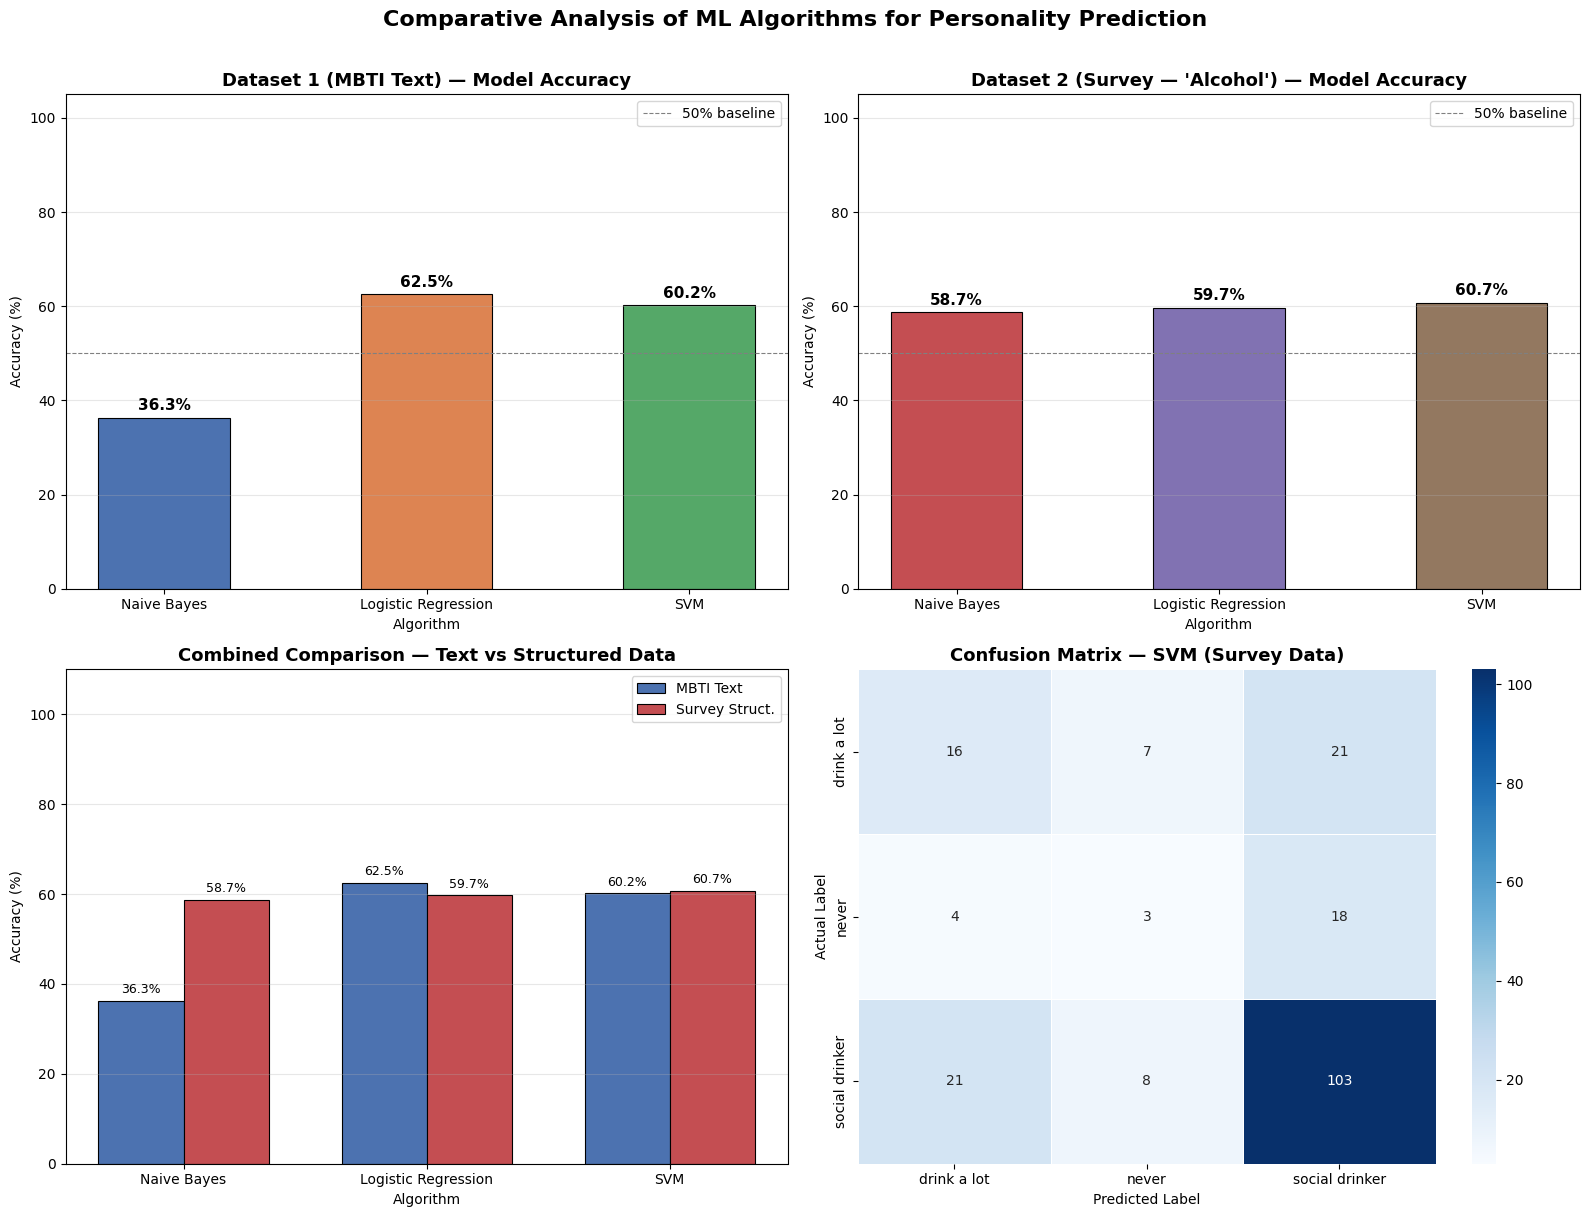

✅ Visualization saved as 'personality_prediction_results.png'


In [ ]:
# ── Shared style settings ────────────────────────────────────
COLORS_TEXT   = ['#4C72B0', '#DD8452', '#55A868']   # Blue, Orange, Green
COLORS_SURVEY = ['#C44E52', '#8172B2', '#937860']   # Red, Purple, Brown
MODEL_NAMES   = ['Naive Bayes', 'Logistic Regression', 'SVM']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Comparative Analysis of ML Algorithms for Personality Prediction',
    fontsize=16, fontweight='bold', y=1.01
)

df_text_results = df_text_results.iloc[:3]
df_survey_results = df_survey_results.iloc[:3]

# ── Plot 1: Dataset 1 — Accuracy Bar Chart ──────────────────
ax1 = axes[0, 0]
bars1 = ax1.bar(
    MODEL_NAMES,
    df_text_results['Accuracy'],
    color=COLORS_TEXT,
    width=0.5,
    edgecolor='black',
    linewidth=0.8
)
ax1.set_title('Dataset 1 (MBTI Text) — Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Algorithm')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 105)
ax1.axhline(y=50, color='grey', linestyle='--', linewidth=0.8, label='50% baseline')
# Add value labels on top of each bar
for bar in bars1:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Dataset 2 — Accuracy Bar Chart ──────────────────
ax2 = axes[0, 1]
bars2 = ax2.bar(
    MODEL_NAMES,
    df_survey_results['Accuracy'],
    color=COLORS_SURVEY,
    width=0.5,
    edgecolor='black',
    linewidth=0.8
)
ax2.set_title(f"Dataset 2 (Survey — '{TARGET_COLUMN}') — Model Accuracy", fontsize=13, fontweight='bold')
ax2.set_xlabel('Algorithm')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 105)
ax2.axhline(y=50, color='grey', linestyle='--', linewidth=0.8, label='50% baseline')
for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# ── Plot 3: Combined Grouped Bar Chart ──────────────────────
ax3 = axes[1, 0]
x      = np.arange(len(MODEL_NAMES))
width  = 0.35

bars3a = ax3.bar(x - width/2, df_text_results['Accuracy'],   width, label='MBTI Text',     color='#4C72B0', edgecolor='black', linewidth=0.8)
bars3b = ax3.bar(x + width/2, df_survey_results['Accuracy'], width, label='Survey Struct.', color='#C44E52', edgecolor='black', linewidth=0.8)

ax3.set_title('Combined Comparison — Text vs Structured Data', fontsize=13, fontweight='bold')
ax3.set_xlabel('Algorithm')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(MODEL_NAMES)
ax3.set_ylim(0, 110)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

for bar in list(bars3a) + list(bars3b):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=9
    )

# ── Plot 4: Confusion Matrix — Best model on Dataset 2 ──────
# Find the best performing model on the survey dataset
best_idx     = df_survey_results['Accuracy'].idxmax()
best_name    = df_survey_results.loc[best_idx, 'Model']
pred_map     = {
    'Naive Bayes'        : y_pred_nb_sv,
    'Logistic Regression': y_pred_lr_sv,
    'SVM'                : y_pred_svm_sv,
}
y_pred_best  = pred_map[best_name]
cm           = confusion_matrix(y_test_sv, y_pred_best)
class_labels = [str(c) for c in le.classes_]

ax4 = axes[1, 1]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=ax4,
    linewidths=0.5,
    linecolor='white'
)
ax4.set_title(f"Confusion Matrix — {best_name} (Survey Data)", fontsize=13, fontweight='bold')
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig('personality_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'personality_prediction_results.png'")



In [ ]:
print(df_text_results)

                 Model  Accuracy  Precision  Recall  F1-Score
0          Naive Bayes     36.31      42.63   36.31     28.10
1  Logistic Regression     62.54      63.88   62.54     59.82


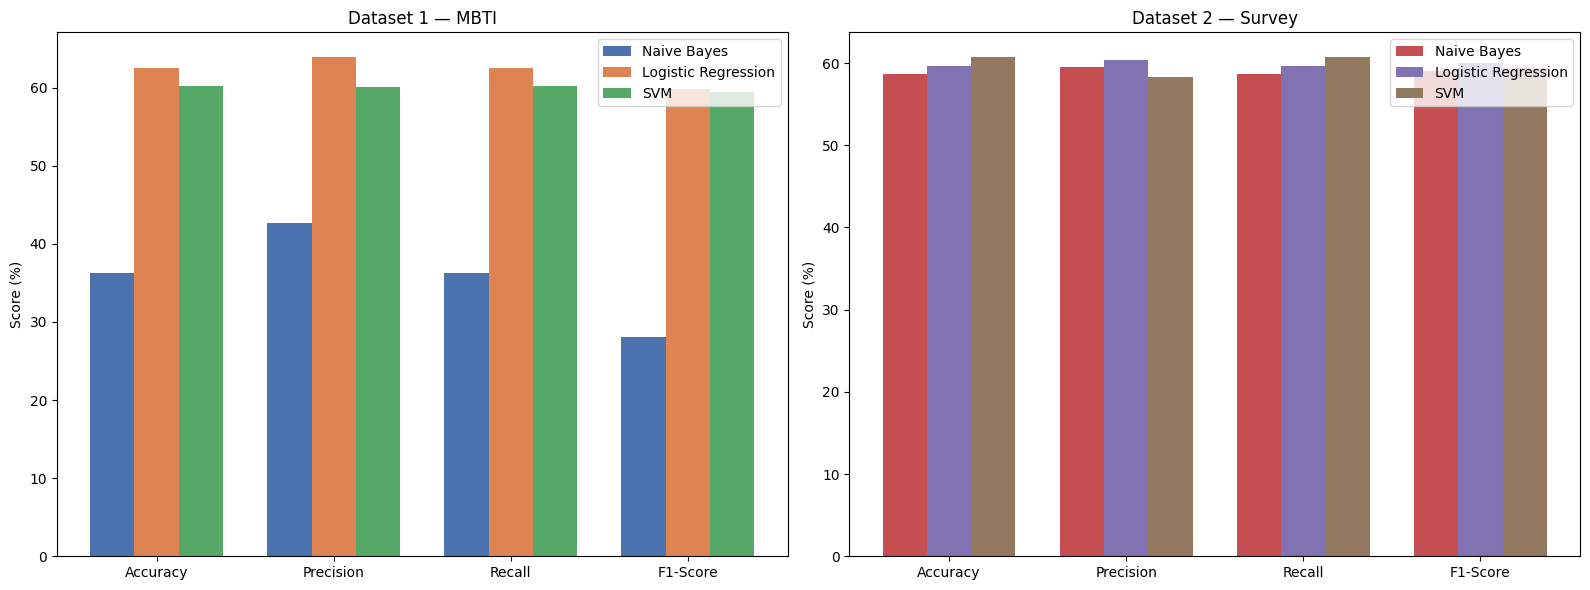

✅ Second visualization DONE


In [ ]:
# ── Additional: All 4 Metrics Side by Side ──────────────────
df_text_results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [36.31, 62.54, 60.17],
    'Precision': [42.63, 63.88, 60.08],
    'Recall': [36.31, 62.54, 60.17],
    'F1-Score': [28.10, 59.82, 59.38]
})

df_survey_results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [58.71, 59.70, 60.70],
    'Precision': [59.56, 60.34, 58.25],
    'Recall': [58.71, 59.70, 60.70],
    'F1-Score': [59.09, 60.00, 59.35]
})

MODEL_NAMES = df_text_results['Model'].tolist()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df_res, title, colors) in zip(
    axes2,
    [
        (df_text_results, 'Dataset 1 — MBTI', COLORS_TEXT),
        (df_survey_results, 'Dataset 2 — Survey', COLORS_SURVEY),
    ]
):
    x = np.arange(len(metrics))
    width = 0.25

    for i in range(len(df_res)):
        vals = [df_res.iloc[i][m] for m in metrics]

        ax.bar(
            x + i * width,
            vals,
            width,
            label=df_res.iloc[i]['Model'],
            color=colors[i]
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics)
    ax.set_title(title)
    ax.set_ylabel("Score (%)")
    ax.legend()

plt.tight_layout()
plt.savefig('detailed_metrics_comparison.png', dpi=300)
plt.show()

print("✅ Second visualization DONE")

**Final Summary Report**

In [ ]:
print("\nDATASET 1 — MBTI TEXT DATA:")
print(df_text_results.to_string(index=False))

best_text = df_text_results.loc[df_text_results['Accuracy'].idxmax()]
print(f"\n    Best Model: {best_text['Model']} with {best_text['Accuracy']}% accuracy")

print(f"\nDATASET 2 — SURVEY STRUCTURED DATA (Target: '{TARGET_COLUMN}'):")
print(df_survey_results.to_string(index=False))

best_sv = df_survey_results.loc[df_survey_results['Accuracy'].idxmax()]
print(f"\n    Best Model: {best_sv['Model']} with {best_sv['Accuracy']}% accuracy")


DATASET 1 — MBTI TEXT DATA:
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes     36.31      42.63   36.31     28.10
Logistic Regression     62.54      63.88   62.54     59.82
                SVM     60.17      60.08   60.17     59.38

    Best Model: Logistic Regression with 62.54% accuracy

DATASET 2 — SURVEY STRUCTURED DATA (Target: 'Alcohol'):
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes     58.71      59.56   58.71     59.09
Logistic Regression     59.70      60.34   59.70     60.00
                SVM     60.70      58.25   60.70     59.35

    Best Model: SVM with 60.7% accuracy
